## Exlporatory Data Analysis

## Introduction
Basic text pre-processing is applied to a dataset of clothing reviews to clean and standardize the text for analysis. The process involves loading and inspecting the dataset, removing noise such as punctuation and digits, normalising the text through lowercasing, tokenisation, and stopword removal, and optionally applying stemming or lemmatisation. A final vocabulary file (vocab.txt) of all unique cleaned words is created to prepare the data for downstream feature generation and machine learning classification tasks.


## Importing libraries 

In [ ]:
import pandas as pd
import numpy as np
import re
import string             
import nltk
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer



nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### Examining and loading data
- Inspection of the data 
- Load the data into proper data structures and prepare for processing.

In [17]:
# Code to inspect the provided data file...

# set file path
file_path = "../kaggle_data/Womens Clothing E-Commerce Reviews.csv"

# load with pandas
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: File not found.")

# display shape and first few rows
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")
display(df.head())

# inspect column names and data types
print("\nColumn information:")
print(df.info())

# check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# quick check rows of feature column
print("\nFirst few sample reviews:")
for i, review in enumerate(df['Review Text'].head(4)):
    print(f"{i+1}. {review}\n")

Dataset loaded successfully!
Dataset contains 23486 rows and 11 columns.



,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses



Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB
None

Missing values per column:
Unnamed: 0                    0
Clothing ID                   0
Age                           0
Ti

## notes
    - 23486 rows -> 23486 individual customer reviews
    - 11 columns -> 10 feature variable columns, 1 id column ("Unamed: 0")


In [62]:
#Basic Statistics

#col "Rating" stats (1-5)
mean_rating = df['Rating'].mean()
print(f'Mean Rating: {mean_rating}')
median_rating = df['Rating'].median()
print(f'Median Rating: {median_rating}')

#col "Recommended" stats (0-1)
mean_recom = df['Recommended IND'].mean()
print(f'Mean Recommended (Value):{mean_recom}') 
median_recom = df['Recommended IND'].median()
print(f'Median Recommended (Value): {median_recom}')

#
sum_0 = 0
sum_1 = 0
for z in df['Recommended IND']:
    if z == 0:
        sum_0 += 1
    else:
        sum_1 += 1

print(f'Count recommnended variable (1) {sum_1} vs Count non-recommended variable (0) {sum_0}')

#correlation numeric features
correlation = df.corr(numeric_only=True)
print('\nCorrelation Matrix:')
print(correlation)

Mean Rating: 4.196031678446734
Median Rating: 5.0
Mean Recommended (Value):0.8223622583666865
Median Recommended (Value): 1.0
Count recommnended variable (1) 19314 vs Count non-recommended variable (0) 4172

Correlation Matrix:
                         Unnamed: 0  Clothing ID       Age    Rating  \
Unnamed: 0                 1.000000    -0.006072 -0.007749 -0.002568   
Clothing ID               -0.006072     1.000000  0.017972 -0.018879   
Age                       -0.007749     0.017972  1.000000  0.026831   
Rating                    -0.002568    -0.018879  0.026831  1.000000   
Recommended IND           -0.003887    -0.016206  0.030622  0.792336   
Positive Feedback Count   -0.002907     0.046356  0.043079 -0.064961   

                         Recommended IND  Positive Feedback Count  
Unnamed: 0                     -0.003887                -0.002907  
Clothing ID                    -0.016206                 0.046356  
Age                             0.030622                 0.0430

## notes
Given the mean and median of 'Ratings' are 4.916 and 5.0 respectively, the distibtion for customer review ratings across
the dataset is skeweded toward higher ratings. Customers are morelikely to leave a positive review than a negative one.

Mean and median of 'Recommended IND' being 0.82 and 1 respectively indicates that 82.2% customers would recommend the product they reviewed (since Recommended IND is a binary value ) and that more than 50% of the customer revews gave a recommended binary value (1). Count of 
recommended values confirms confirms majority positive reviews.

Correlation matrix showing one noteable strong positive correlation between Recommended IND and Rating. Few positive correlations
but mostly, very small for most pairs, therefore largely no correlation between most feature variables.


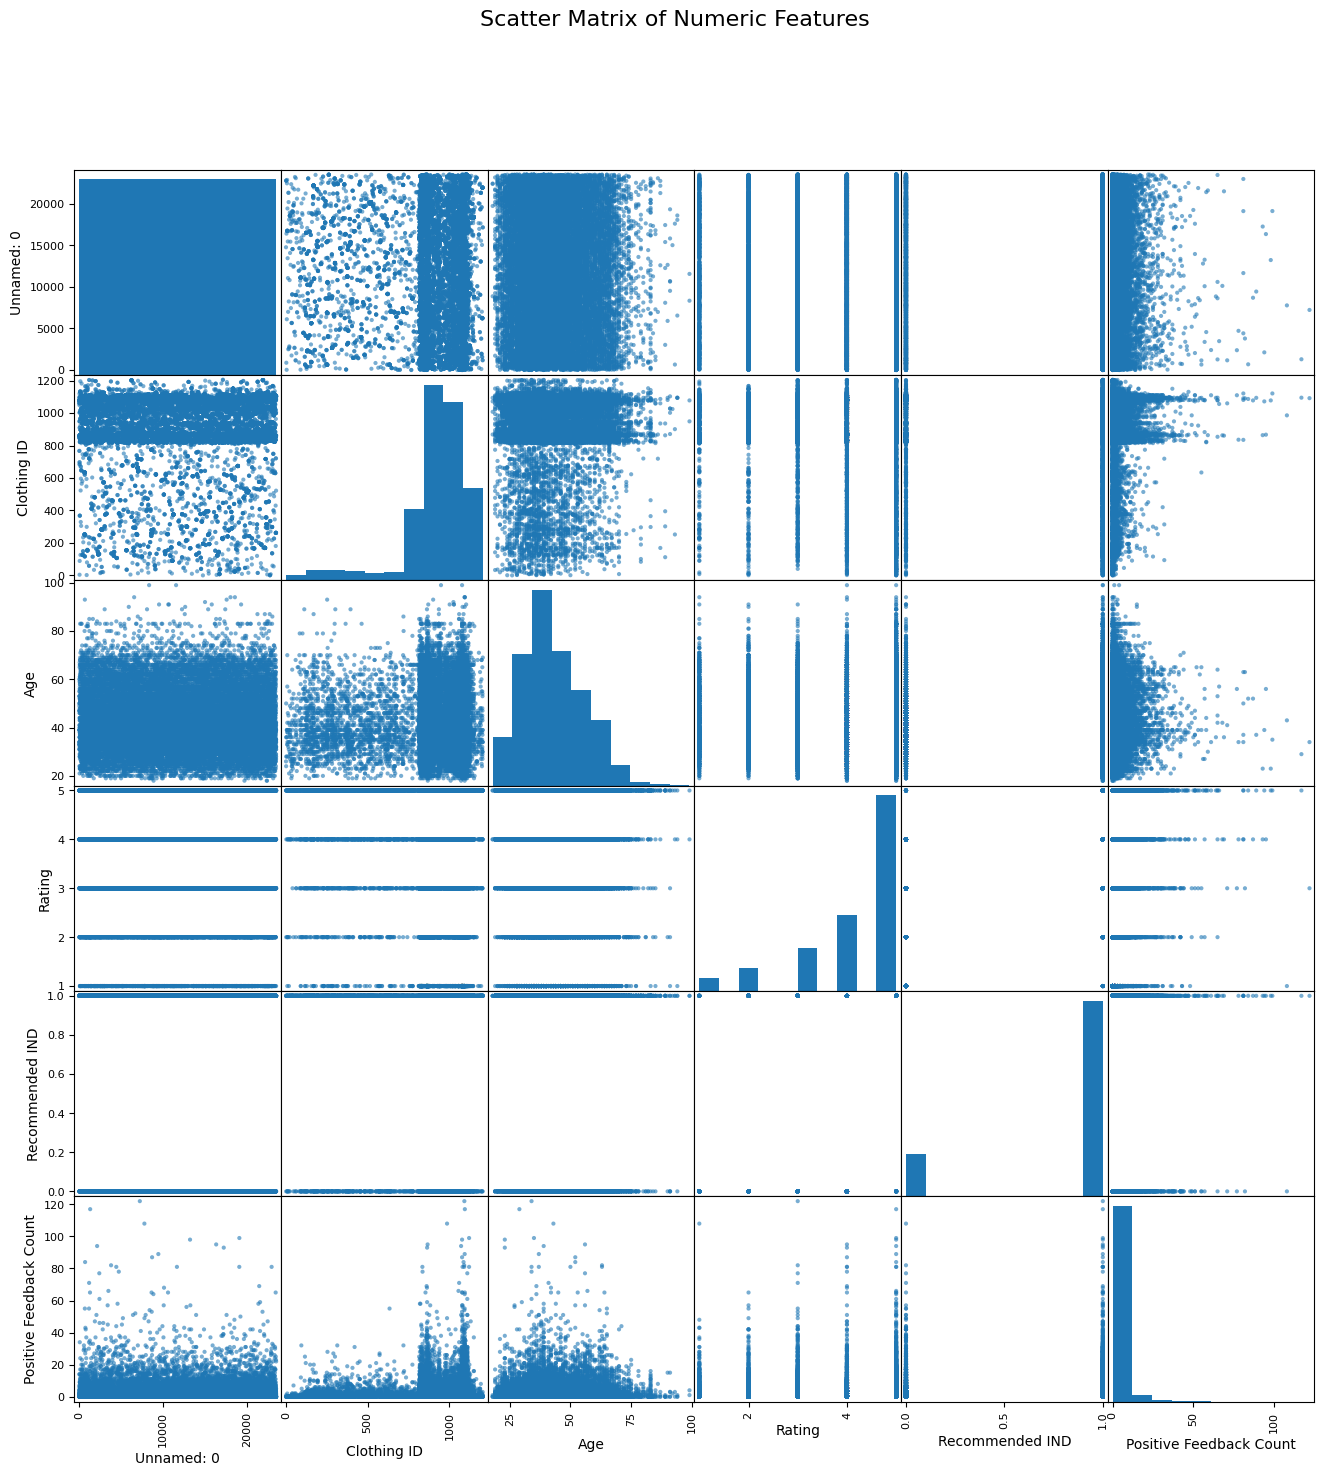

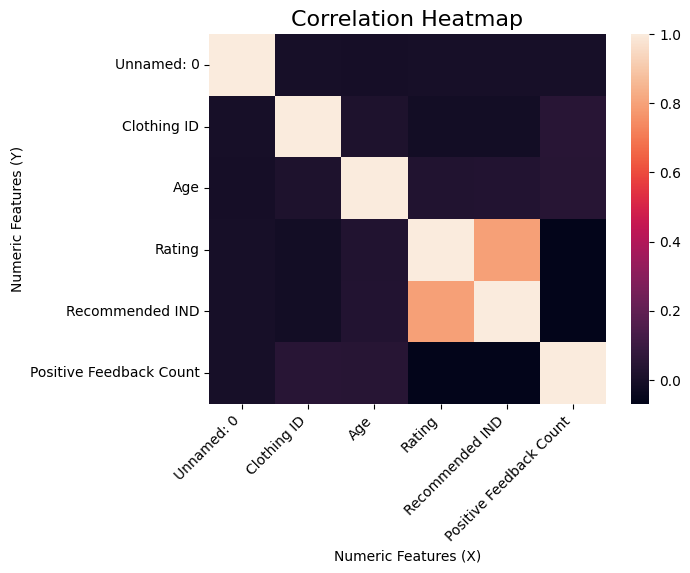

In [ ]:
#basic visualizations
import matplotlib.pyplot as plt 
import seaborn as sns

#df scatter plot 
scat_axes = pd.plotting.scatter_matrix(df.select_dtypes(include='number'), figsize=(16,16), alpha = 0.6)
scat_plot = scat_axes[0, 0]  
scat_plot.figure.suptitle('Scatter Matrix of Numeric Features', fontsize=16)
plt.show()


#heatmap for correlation matrix
corr_plot = sns.heatmap(df.corr(numeric_only=True))
corr_plot.set_title('Correlation Heatmap', fontsize = 16)
corr_plot.set_xlabel('Numeric Features (X)', fontsize = 10)
corr_plot.set_ylabel('Numeric Features (Y)', fontsize = 10)
corr_plot.set_xticklabels(corr_plot.get_xticklabels(), rotation=45, ha='right') #rortate x-axis label readability
plt.show()




### 1.2 Pre-processing data
Perform the required text pre-processing steps.

In [3]:
# code to perform the task...

# fix column names by stripping whitespace
df.columns = df.columns.str.strip()

# load stopwords list
with open('stopwords_en.txt', 'r', encoding='utf-8') as f:
    stop_words = set(f.read().split())

# define tokenizer regex
token_pattern = re.compile(r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?")

def tokenize(text):
    return token_pattern.findall(text)

#  pre-processing function
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Tokenize
    tokens = tokenize(text)
    # Remove short words (<2 characters) and stopwords
    tokens = [t for t in tokens if len(t) >= 2 and t not in stop_words]
    return tokens

# appply pre-processing to Review Text 
df['tokens'] = df['Review Text'].astype(str).apply(preprocess_text)

# remove words that appear only once in the entire dataset 
all_tokens = [word for tokens in df['tokens'] for word in tokens]
term_freq = Counter(all_tokens)
df['tokens'] = [[word for word in tokens if term_freq[word] > 1] for tokens in df['tokens']]

# remove top 20 most frequent words (document frequency) 
def document_frequency(tokens_list):
    df_counter = Counter()
    for tokens in tokens_list:
        for word in set(tokens):
            df_counter[word] += 1
    return df_counter

doc_freq = document_frequency(df['tokens'])
top_20 = set([w for w, _ in doc_freq.most_common(20)])
df['tokens'] = [[word for word in tokens if word not in top_20] for tokens in df['tokens']]

# create processed review text (space-separated tokens)
df['Processed_Review'] = df['tokens'].apply(lambda x: ' '.join(x))

# preview results BEFORE saving

print("Quick preview!!")
print(f"Total processed reviews: {len(df)}")
print(f"Vocabulary size (pre-saving): {len(set([w for t in df['tokens'] for w in t]))}")
print("\nFirst couple sample cleaned reviews:")
print(df[['Review Text', 'Processed_Review']].head(8))
print("\nPreview of token column:")
print(df['tokens'].head(8))


Quick preview!!
Total processed reviews: 19662
Vocabulary size (pre-saving): 7529

First couple sample cleaned reviews:
                                         Review Text  \
0  I had such high hopes for this dress and reall...   
1  I love, love, love this jumpsuit. it's fun, fl...   
2  This shirt is very flattering to all due to th...   
3  I love tracy reese dresses, but this one is no...   
4  I aded this in my basket at hte last mintue to...   
5  I ordered this in carbon for store pick up, an...   
6  I love this dress. i usually get an xs but it ...   
7  I'm 5"5' and 125 lbs. i ordered the s petite t...   

                                    Processed_Review  
0  high hopes wanted work initially petite usual ...  
1      jumpsuit fun flirty fabulous time compliments  
2  shirt due adjustable front tie length leggings...  
3  tracy reese dresses petite feet tall brand pre...  
4  basket hte person store pick teh pale hte gorg...  
5  carbon store pick ton stuff pair skirts pa

## Saving required outputs
Save the requested information as per specification.
- vocab.txt

In [4]:
# code to save output data...

#save processed.csv
df.to_csv('processed.csv', index=False)

# build and save vocab.txt
vocab = sorted(set([word for tokens in df['tokens'] for word in tokens]))
vocab_dict = {word: i for i, word in enumerate(vocab)}

with open('vocab.txt', 'w', encoding='utf-8') as f:
    for word, idx in vocab_dict.items():
        f.write(f"{word}:{idx}\n")

## Summary

In this task, basic text pre-processing was performed on the clothing review dataset to clean and standardize the text for downstream NLP tasks. The steps included lowercasing, tokenization using a specified regex, removing short words, stopwords, words that appear only once, and the top 20 most frequent words. This resulted in a processed dataset (processed.csv) and a unigram vocabulary (vocab.txt) containing 7,529 unique word that were sorted alphabetically and indexed. The processed reviews and vocabulary now provide a consistent foundation for later tasks in feature representation.



## Feature Representation
This part of the eda focuses on generating feature representations for clothing reviews and building machine learning models to classify whether a review recommends the product. I will transform the cleaned review text into numerical representations, including a bag-of-words count vector and word embedding-based vectors (both weighted and unweighted). In the next section I will usethese features to train and evaluate classification models, comparing different representations and investigating the impact of including additional information such as the review title. The objective is to create structured, machine-readable data and determine which features and models provide the most accurate predictions.


## Generating Feature Representations for Clothing Items Reviews

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

## Load processed csv

In [2]:


#load pre-processed review text
df = pd.read_csv("processed.csv")  # from task 1
print(f"Loaded {len(df)} processed reviews.")

#since the tokens in processed.csv are in a list 
#the code below converts back to strings so we can 
#iterate over, count word occurences and complete
#bag of words vectorization

# convert token columns to list (from string)
def str_to_list(token_str):
    token_str = token_str.strip()[1:-1]  # remove brackets []
    if not token_str:
        return []
    return [w.strip().strip("'").strip('"') for w in token_str.split(',')]

df['tokens'] = df['tokens'].apply(str_to_list)


# Replace any NaN in Processed_Review with empty string
df['Processed_Review'] = df['Processed_Review'].fillna("")

# Now you can safely fit the vectorizer
tfidf_vectorizer = TfidfVectorizer()
tfidf_vectorizer.fit(df['Processed_Review'])
tfidf_scores = dict(zip(tfidf_vectorizer.get_feature_names_out(), tfidf_vectorizer.idf_))

Loaded 19662 processed reviews.


## Load vocab.txt 

In [3]:
#load vocab.txt
vocab_dict = {}
with open('vocab.txt', 'r', encoding='utf-8') as f:
    for line in f:
        word, idx = line.strip().split(':')
        vocab_dict[word] = int(idx)

vocab_list = sorted(vocab_dict.keys())
print(f"Vocabulary size: {len(vocab_list)}")

Vocabulary size: 7529


## Generate Bag Of Words Count Vector

In [4]:
# create a an empty list that will have words appear in each review and their count
count_vectors = []

for i, tokens in enumerate(df['tokens']):
    word_counts = Counter(tokens)
    # convert tokens to index:count format using Task 1 vocab.text
    word_index_count = [f"{vocab_dict[w]}:{c}" for w, c in word_counts.items() if w in vocab_dict]
    line = f"#{i}," + ",".join(word_index_count)
    count_vectors.append(line)

# view first few vectors
for line in count_vectors[:8]:
    print(line)

#0,3010:1,3087:1,7207:1,7406:1,3258:1,4639:2,7092:1,2602:1,4427:1,2289:1,7520:1,5260:1,3934:1,2892:2,4234:1,687:1,6726:1,3549:2,1028:1,4224:2,3552:1,3193:1,3832:1,1716:1,2481:1,5668:1,1792:1,7522:1
#1,3403:1,2667:1,2502:1,2284:1,6739:1,1287:1
#2,5736:2,1988:1,86:1,2646:1,6716:1,3595:1,3584:1,5924:1,4506:1,925:1
#3,6809:1,5176:1,1950:1,4639:1,2373:1,6548:1,721:1,4912:1,4484:1,3748:1,5900:2,3707:1,2657:1,4472:1,2610:1,6290:1,179:1,5764:1,2083:1,2711:1,3168:1,6366:1,7406:1,5332:1
#4,449:1,3120:4,4628:1,6274:1,4663:1,6601:1,4513:1,2803:1,6907:1,4883:1,408:1,7469:1,818:1,4639:1,1630:1,2050:1,4528:1,5903:1,4363:1
#5,922:1,6274:1,4663:1,6774:1,6350:1,4503:1,5903:2,4528:2,1012:1,5720:1,4604:1,2459:1,560:2,537:1,5925:1,3707:1,4639:1,3729:1,7478:1,7348:1,3628:1,6037:1,3120:1,5969:1
#6,7469:1,5471:1,6012:1,842:1,2382:1,7092:1,5320:1,2451:1,6366:1
#7,3559:1,4639:2,3835:1,3595:1,3707:1,6938:1,7469:1,5202:1,5320:1,1950:1,849:1,1518:1,5968:1,4621:1,6012:1,6726:1,4550:1,7406:1,6898:1,3714:1,6987:1


## Models based on Word Embeddings

In [5]:
# load GloVe embeddings
# 100d GloVe file downloaded as 'glove.6B.100d.txt'
glove_file = 'glove.6B.100d.txt' 
glove_model = {}
# read all word embeddings from GloVe and store each word with vector in dictionary
with open(glove_file, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        word = parts[0]
        vector = np.array(parts[1:], dtype=np.float32)
        glove_model[word] = vector

print(f"Loaded {len(glove_model)} GloVe word vectors") 

# prepare tf-idf vectorizer on processed reviews
tfidf_vectorizer = TfidfVectorizer()
tfidf_vectorizer.fit(df['Processed_Review'])
tfidf_scores = dict(zip(tfidf_vectorizer.get_feature_names_out(), tfidf_vectorizer.idf_))

# empty lists to store representations
embedding_unweighted = []
embedding_weighted = []

# loop over each tokenized review
for review in df['tokens']:
    vectors = []
    weights = []
    
    for word in review:
        if word in glove_model:
            vectors.append(glove_model[word])
            # weighted: use TF-IDF score if available
            weights.append(tfidf_scores.get(word, 1.0))

    #if review has known words
    if vectors:
        # unweighted: simple average of embeddings
        embedding_unweighted.append(np.mean(vectors, axis=0))
        # weighted: TF-IDF weighted average
        weighted_vec = np.average(vectors, axis=0, weights=weights)
        embedding_weighted.append(weighted_vec)

    # if no known words, zero vector    
    else:
        embedding_unweighted.append(np.zeros(len(next(iter(glove_model.values())))))
        embedding_weighted.append(np.zeros(len(next(iter(glove_model.values())))))

print("Generated embedding-based unweighted and TF-IDF weighted feature vectors using GloVe")

Loaded 400000 GloVe word vectors
Generated embedding-based unweighted and TF-IDF weighted feature vectors using GloVe


### Saving outputs
Save the count vector representation as per spectification.
- count_vectors.txt

In [6]:
# code to save output data...

#Save Bag of Words count vectors
with open('count_vectors.txt', 'w', encoding='utf-8') as f:
    for line in count_vectors:
        f.write(line + "\n")

print("Bag of Words saved as count_vectors.txt")

# Save unweighted embeddings
with open('embedding_vectors.txt', 'w', encoding='utf-8') as f:
    for vec in embedding_unweighted: 
        line = ",".join([str(x) for x in vec])
        f.write(line + "\n")
print("Unweighted embeddings saved to embedding_vectors.txt")

# Save TF-IDF weighted embeddings
with open('tfidf_embedding_vectors.txt', 'w', encoding='utf-8') as f:
    for vec in embedding_weighted:  
        line = ",".join([str(x) for x in vec])
        f.write(line + "\n")
print("TF-IDF weighted embeddings saved to tfidf_embedding_vectors.txt")

Bag of Words saved as count_vectors.txt
Unweighted embeddings saved to embedding_vectors.txt
TF-IDF weighted embeddings saved to tfidf_embedding_vectors.txt


## Clothing Review Classification

In [7]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

## Load Dataset and Label

In [1]:
# load CSV file
df = pd.read_csv('assignment3.csv')

# check column names
print(df.columns)

# load target variable
y = df['Recommended IND'].values

NameError: name 'pd' is not defined

## Load Feature Representations

In [9]:
# Bag of Words

count_vectors_list = []

# parse count_vectors.txt file
with open('count_vectors.txt', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line[1:].split(',')  
        vec_dict = {}
        for item in parts[1:]: 
            if ':' in item:
                idx, count = item.split(':')
                vec_dict[int(idx)] = int(count)
        count_vectors_list.append(vec_dict)

# confirm how many reviews were successfully read from the file.
print(f"Parsed {len(count_vectors_list)} count vectors")

#calculate vocabulary size and initialise dense numpy array
non_empty_dicts = [d for d in count_vectors_list if d]
vocab_size = max(max(d.keys()) for d in non_empty_dicts) + 1
X_count = np.zeros((len(count_vectors_list), vocab_size))

#enumerate array
for i, d in enumerate(count_vectors_list):
    for idx, count in d.items():
        X_count[i, idx] = count

Parsed 19662 count vectors


In [10]:
#load word embeddings models

# unweighted embeddings
embedding_vectors_unweighted = np.loadtxt('embedding_vectors.txt', delimiter=',')
print(f"Unweighted embeddings shape: {embedding_vectors_unweighted.shape}")
# tf-idf weighted embeddings
embedding_vectors_tfidf = np.loadtxt('tfidf_embedding_vectors.txt', delimiter=',')
print(f"TF-IDF weighted embeddings shape: {embedding_vectors_tfidf.shape}")

Unweighted embeddings shape: (19662, 100)
TF-IDF weighted embeddings shape: (19662, 100)


## Standardise Features

In [11]:
# scalar object to normalise the unweighted embedding vectors
scaler_unweighted = StandardScaler()
X_unweighted_scaled = scaler_unweighted.fit_transform(embedding_vectors_unweighted)

# scalar object to normalise the TF-IDF weighted embedding vectors
scaler_tfidf = StandardScaler()
X_tfidf_scaled = scaler_tfidf.fit_transform(embedding_vectors_tfidf)

## Q1: Language Model Comparison

In this section, we compare the three feature representations generated for classifying whether a clothing review is recommended:

1. Bag-of-Words (Count vectors)
2. Unweighted word embeddings (GloVe)
3. TF-IDF weighted word embeddings (GloVe)

We use Logistic Regression with 5-fold cross-validation to evaluate model performance.

In [12]:
# create  K-Fold CV object
kf = KFold(n_splits=5, shuffle=True, random_state=1)

# Function to evaluate
def evaluate_model(X, y):
    model = LogisticRegression(max_iter=1000)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    print(f"Mean Accuracy: {scores.mean():.4f}, Std: {scores.std():.4f}")
    return scores

print("Bag of Words Model:")
evaluate_model(X_count, y)

print("\nUnweighted Embeddings Model:")
evaluate_model(X_unweighted_scaled, y)

print("\nTF-IDF Weighted Embeddings Model:")
evaluate_model(X_tfidf_scaled, y)

Bag of Words Model:
Mean Accuracy: 0.8745, Std: 0.0044

Unweighted Embeddings Model:
Mean Accuracy: 0.8414, Std: 0.0046

TF-IDF Weighted Embeddings Model:
Mean Accuracy: 0.8389, Std: 0.0046


array([0.83396898, 0.84134249, 0.84028484, 0.83341811, 0.84562564])

In [15]:
#webapp

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from joblib import dump
import pandas as pd

# --- Load processed data from Task 1 ---
processed_df = pd.read_csv("processed.csv")

# Fill missing text
processed_df["Processed_Review"] = processed_df["Processed_Review"].fillna("")

# Recreate TF-IDF features using the cleaned review text
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(processed_df["Processed_Review"])

# The target column comes from the original assignment3.csv file
labels_df = pd.read_csv("assignment3.csv")
y = labels_df["Recommended IND"]

# --- Train final model ---
model = LogisticRegression(max_iter=1000)
model.fit(X_tfidf, y)

# --- Save both vectorizer and model ---
dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")
dump(model, "logreg_tfidf_model.pkl")

print(" Saved tfidf_vectorizer.pkl and logreg_tfidf_model.pkl")



✅ Saved tfidf_vectorizer.pkl and logreg_tfidf_model.pkl


#### Results Summary

- Bag-of-Words Model: Mean Accuracy ~0.8745  
- Unweighted Embeddings Model: Mean Accuracy ~0.8414  
- TF-IDF Weighted Embeddings Model: Mean Accuracy ~0.8389  

**Observation:**  
For this dataset, the Bag-of-Words model achieved the highest accuracy, indicating that traditional count-based features capture 
recommendation signals better than pre-trained embeddings. Both weighted and unweighted embeddings performed slightly worse, 
possibly because embeddings may dilute review-specific information.

### Q2: Does more information improve accuracy?

Here, we explore whether including the review title in addition to the description improves model performance.  
We consider three scenarios:

1. Only title of the review
2. Only description/text of the review
3. Concatenated title + description

The same models (Bag-of-Words, Unweighted embeddings, TF-IDF weighted embeddings) are applied.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer


kf = KFold(n_splits=5, shuffle=True, random_state=1)

# bag of words for Title Only
count_vectorizer_title = CountVectorizer()
X_title = count_vectorizer_title.fit_transform(df['Title'].astype(str))

# bag of words for Review Text Only
count_vectorizer_text = CountVectorizer()
X_text = count_vectorizer_text.fit_transform(df['Review Text'].astype(str))

# bag of words for Combined Title + Review Text
df['title_description'] = df['Title'].astype(str) + " " + df['Review Text'].astype(str)
count_vectorizer_combined = CountVectorizer()
X_combined = count_vectorizer_combined.fit_transform(df['title_description'])

# target variable
y = df['Recommended IND'].values

# function to evaluation
def evaluate_bow_model(X, y, label):
    model = LogisticRegression(max_iter=1000)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    print(f"{label}: Mean Accuracy = {scores.mean():.4f}, Std = {scores.std():.4f}")
    return scores.mean(), scores.std()

# evaluate all three cases
title_acc, title_std = evaluate_bow_model(X_title, y, "Title Only")
text_acc, text_std = evaluate_bow_model(X_text, y, "Review Text Only")
combined_acc, combined_std = evaluate_bow_model(X_combined, y, "Title + Review Text")

# summarize results
results = {
    'Title Only': (title_acc, title_std),
    'Review Text Only': (text_acc, text_std),
    'Title + Review Text': (combined_acc, combined_std)
}
results

In [ ]:
from sklearn.linear_model import LogisticRegression
import joblib

# Choose your best-performing feature set, e.g., Bag-of-Words (X_count)
print("Training final Logistic Regression model on full dataset...")

# Train final model
final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_count, y)

# Save model and vectorizer
joblib.dump(final_model, "logreg_tfidf_model.pkl")

# If you want to include the TF-IDF vectorizer from Task 2:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()
tfidf_vectorizer.fit(df['Processed_Review'])
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!)

## Results Summary and Observation

The Title + Review Text combination achieved the highest mean accuracy (0.8998) with the lowest standard deviation (0.0041), outperforming 
both individual inputs — Title Only (0.8854) and Review Text Only (0.8857).

This indicates that including more textual information provides the model with a richer context, leading to better classification performance and more consistent results across folds. Therefore, combining the title 
and review text improves model accuracy and stability.

## Summary
I created different feature representations for the clothing reviews: Bag-of-Words, unweighted GloVe embeddings, and TF-IDF-weighted embeddings. These turned the text into numerical vectors that can be used by machine learning models.

Ie used these features to classify whether a review recommends a product. Bag-of-Words worked best on its own, and combining the review title with the text improved accuracy even more, showing that using more information helps the model make better predictions.